# Practice: Merging and Datatypes

In this exercise, you will practice changing datatypes, merging two datasets together, and finally visualizing the result.

## 0. Introduction: pd.concat and pd.merge with Real Data

Before we dive into the full analysis, let's explore `pd.concat` and `pd.merge` using real data from the World Bank.

In [55]:
import pandas as pd
import requests
import io

def get_wb_data(indicator, country, start_year, end_year):
    url = f'https://api.worldbank.org/v2/country/{country}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000'
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

# Pre-loading some data for examples
usa_pop = get_wb_data('SP.POP.TOTL', 'USA', 2020, 2022)
can_pop = get_wb_data('SP.POP.TOTL', 'CAN', 2020, 2022)
usa_gdp = get_wb_data('NY.GDP.PCAP.CD', 'USA', 1999, 2022)

In [56]:
usa_pop

,countryiso3code,date,value
0,USA,2022,334017321
1,USA,2021,332099760
2,USA,2020,331577720


In [57]:
usa_gdp

,countryiso3code,date,value
0,USA,2022,76657.248884
1,USA,2021,70205.050916
2,USA,2020,63515.949181
3,USA,2019,64746.450678
4,USA,2018,62499.874439
5,USA,2017,59635.098440
6,USA,2016,57638.101837
7,USA,2015,56572.918900
8,USA,2014,54973.420752
9,USA,2013,53179.012763


In [58]:
can_pop

,countryiso3code,date,value
0,CAN,2022,38935934
1,CAN,2021,38239864
2,CAN,2020,38028638


### 0.1 pd.concat (Stacking Row-wise)
We can use `pd.concat` to combine the USA population data and Canada population data into one table.

In [59]:
# Combine them vertically
combined_pop = pd.concat([usa_pop, can_pop], axis='rows')
combined_pop

,countryiso3code,date,value
0,USA,2022,334017321
1,USA,2021,332099760
2,USA,2020,331577720
0,CAN,2022,38935934
1,CAN,2021,38239864
2,CAN,2020,38028638


In [60]:
def get_wb_data2(indicator, country_list, start_year, end_year):
    url = f'https://api.worldbank.org/v2/country/{country_list}/indicator/{indicator}?date={start_year}:{end_year}&format=json&per_page=1000'
    response = requests.get(url)
    data = response.json()[1]
    df = pd.json_normalize(data)
    return df[['countryiso3code', 'date', 'value']]

combined_pop2 = get_wb_data2('SP.POP.TOTL', 'USA;CAN', 2020, 2022)
combined_pop2

,countryiso3code,date,value
0,CAN,2022,38935934
1,CAN,2021,38239864
2,CAN,2020,38028638
3,USA,2022,334017321
4,USA,2021,332099760
5,USA,2020,331577720


### 0.2 pd.concat (Stacking Column-wise)
We can use `pd.concat` to combine the USA population data and Canada population data into one table.

In [61]:
usa_pop_renamed = usa_pop.rename(columns={'value': 'population'})
usa_gdp_renamed = usa_gdp.rename(columns={'value': 'gdp_per_capita'})
usa_gdp_renamed.head(2)

,countryiso3code,date,gdp_per_capita
0,USA,2022,76657.248884
1,USA,2021,70205.050916


In [62]:
# Combine them vertically
combined_pop = pd.concat([usa_pop_renamed, usa_gdp_renamed], axis='columns')
combined_pop

,countryiso3code,date,population,countryiso3code,date,gdp_per_capita
0,USA,2022,334017321.0,USA,2022,76657.248884
1,USA,2021,332099760.0,USA,2021,70205.050916
2,USA,2020,331577720.0,USA,2020,63515.949181
3,NaN,NaN,NaN,USA,2019,64746.450678
4,NaN,NaN,NaN,USA,2018,62499.874439
5,NaN,NaN,NaN,USA,2017,59635.098440
6,NaN,NaN,NaN,USA,2016,57638.101837
7,NaN,NaN,NaN,USA,2015,56572.918900
8,NaN,NaN,NaN,USA,2014,54973.420752
9,NaN,NaN,NaN,USA,2013,53179.012763


### 0.3 pd.merge (Joining Data)
We can use `pd.merge` to join the USA Population data with the USA GDP data based on the date.

In [63]:
merged_usa = pd.merge(usa_pop_renamed, usa_gdp_renamed, on=['countryiso3code', 'date'])
merged_usa

,countryiso3code,date,population,gdp_per_capita
0,USA,2022,334017321,76657.248884
1,USA,2021,332099760,70205.050916
2,USA,2020,331577720,63515.949181


## 1. Merging with Functions
Apply concepts in a structured way using simple functions. We will download macroeconomic and OECD data. Run the cell below.

In [64]:
def download_macro_data(url):
    print(f"Fetching macroeconomic data from: {url}")
    df = pd.read_stata(url)
    return df

def download_oecd_data(url):
    print(f"Fetching OECD data from: {url}")
    response = requests.get(url)
    response.raise_for_status()
    data = io.StringIO(response.text)
    df = pd.read_csv(data)
    return df

url_macro = 'https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_infl.dta'
url_oecd = "https://sdmx.oecd.org/public/rest/data/OECD.SDD.TPS,DSD_PDB@DF_PDB_ULC_Q,1.0/.Q.......?startPeriod=1990-Q4&format=csv"

df_macro_raw = download_macro_data(url_macro)
df_oecd_raw = download_oecd_data(url_oecd)

Fetching macroeconomic data from: https://github.com/KMueller-Lab/Global-Macro-Database/raw/refs/heads/main/data/final/chainlinked_infl.dta
Fetching OECD data from: https://sdmx.oecd.org/public/rest/data/OECD.SDD.TPS,DSD_PDB@DF_PDB_ULC_Q,1.0/.Q.......?startPeriod=1990-Q4&format=csv


In [65]:
df_macro_raw.head(2)

,ISO3,year,ADB_infl,AHSTAT_infl,AMF_infl,BCEAO_infl,BIS_infl,BORDO_infl,CEPAC_infl,EUS_infl,...,OECD_KEI_infl,WB_CC_infl,WDI_infl,WDI_ARC_infl,CS1_infl,CS2_infl,infl,chainlinking_ratio,source,source_change
0,ZWE,2029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.131044,1.0,IMF_WEO,NaN
1,ZWE,2028.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.108963,1.0,IMF_WEO,NaN


In [66]:
df_oecd_raw.head(2)

,DATAFLOW,REF_AREA,FREQ,MEASURE,ACTIVITY,UNIT_MEASURE,PRICE_BASE,TRANSFORMATION,ADJUSTMENT,CONVERSION_TYPE,TIME_PERIOD,OBS_VALUE,OBS_STATUS,UNIT_MULT,BASE_PER,DECIMALS
0,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),SWE,Q,GDPEMP,_T,PP,Q,G1,S,NC,1993-Q2,1.805471,A,0,NaN,2
1,OECD.SDD.TPS:DSD_PDB@DF_PDB_ULC_Q(1.0),SWE,Q,GDPEMP,_T,PP,Q,G1,S,NC,1993-Q3,1.243324,A,0,NaN,2


## 2. Filtering Data
Filter the data for New Zealand (NZL) and rename columns. Try to fill in the missing code!

In [67]:
def filter_rename_macro_nz(df, country):
    df_nz = df.query(f"ISO3 == '{country}'")[['ISO3', 'year', 'OECD_KEI_infl', 'BIS_infl']].dropna()
    df_nz = df_nz.rename({"ISO3":'country', "year":'date'}, axis=1)
    return df_nz

In [68]:
df_macro_nz = filter_rename_macro_nz(df_macro_raw.copy(), 'ESP')
df_macro_nz.head(2)

,country,date,OECD_KEI_infl,BIS_infl
14299,ESP,2023.0,3.532361,3.532361
14300,ESP,2022.0,8.390576,8.390576


In [69]:
def filter_rename_oecd_nz(df):
    # YOUR CODE HERE to filter for ESP, MEASURE=='ULCE', UNIT_MEASURE=='PA'
    cols = ['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE', 'MEASURE', 'UNIT_MEASURE']
    df_nz = df[cols].query("REF_AREA == 'ESP' & MEASURE=='ULCE' & UNIT_MEASURE == 'PA'")
    df_nz = df_nz.rename({"REF_AREA":'country', "TIME_PERIOD":'date', 'OBS_VALUE':'ULCE'}, axis=1).drop(["MEASURE", "UNIT_MEASURE"], axis=1)
    return df_nz

In [70]:
df_oecd_nz = filter_rename_oecd_nz(df_oecd_raw.copy())
df_oecd_nz.head(2)

,country,date,ULCE
15800,ESP,2016-Q1,-1.329899
16834,ESP,2014-Q2,0.099907


In [71]:
df_oecd_nz.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 15800 to 26069
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  120 non-null    object 
 1   date     120 non-null    object 
 2   ULCE     120 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.8+ KB


## 3. Convert Datetimes
Convert your data columns to datetime types.

In [72]:
def convert_datetime(df_oecd, df_macro):
    df_oecd['date'] = pd.PeriodIndex(df_oecd['date'], freq='Q').to_timestamp() #.date
    df_macro['date'] = pd.to_datetime(df_macro['date'], format='%Y')#.dt.date
    return df_oecd, df_macro

df_oecd_nz_dt, df_macro_nz_dt = convert_datetime(df_oecd_nz.copy(), df_macro_nz.copy())

In [73]:
df_oecd_nz_dt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 15800 to 26069
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   country  120 non-null    object        
 1   date     120 non-null    datetime64[ns]
 2   ULCE     120 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 3.8+ KB


In [74]:
df_oecd_nz.head(1)

,country,date,ULCE
15800,ESP,2016-Q1,-1.329899


In [75]:
df_oecd_nz_dt.head(1)

,country,date,ULCE
15800,ESP,2016-01-01,-1.329899


## 4. Set Index
Set both 'country' and 'date' as index for merging properly.

In [76]:
def set_index(df_oecd, df_macro):
    df_macro = df_macro.set_index(['country', 'date'])
    df_oecd = df_oecd.set_index(['country', 'date'])
    return df_oecd, df_macro

df_oecd_indexed, df_macro_indexed = set_index(df_oecd_nz_dt.copy(), df_macro_nz_dt.copy())

## 5. Merging
Merge the macroeconomic and OECD datasets together on their indices.

In [77]:
def merge_data(df_macro, df_oecd):
    # YOUR CODE HERE
    df_merge = pd.merge(
        df_macro,
        df_oecd,
        right_index=True,
        left_index=True,
        how='inner'
    )
    return df_merge

df_merged = merge_data(df_macro_indexed, df_oecd_indexed)
df_merged.head()

OECD_KEI_infl  BIS_infl      ULCE
country date                                         
ESP     2023-01-01       3.532361  3.532361  4.725747
        2022-01-01       8.390576  8.390576  1.181960
        2021-01-01       3.093135  3.093135  4.011040
        2020-01-01      -0.322753 -0.322753  6.180105
        2019-01-01       0.699519  0.699519  3.595261

## 6. Visualizing the Merge
Let's visualize the relationship between OECD inflation and BIS inflation.

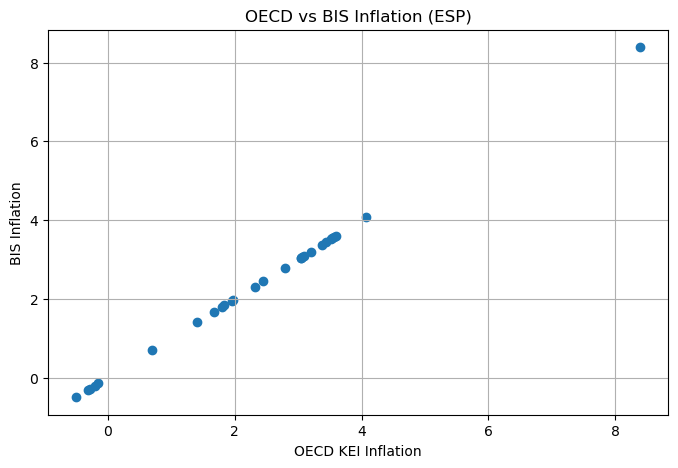

In [79]:
import matplotlib.pyplot as plt
# Create scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df_merged['OECD_KEI_infl'], df_merged['BIS_infl'])
plt.xlabel('OECD KEI Inflation')
plt.ylabel('BIS Inflation')
plt.title('OECD vs BIS Inflation (ESP)')
plt.grid(True)
plt.show()